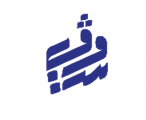
#  **Notebook d'Analyse de Qualité des Donnée(Data Quality)**
# **Sujet : E-Commerce Sougui Shop**

# Data Quality – Projet BI E-commerce

Objectif :
 1. Importer des données depuis différents formats (PDF, Excel, CSV, XML, etc.)
 2. Analyser la qualité des données selon plusieurs dimensions
 3. Générer des rapports et visualisations
 4. Proposer des corrections et améliorations

<span style="color:#B39DDB ">

## **Installation et configuration**
</span>

In [51]:
!pip install pandas numpy openpyxl xlrd odfpy pyxlsb pdfplumber lxml beautifulsoup4 matplotlib seaborn plotly missingno -q

<span style="color:#B39DDB ">

##  **Importation des bibliothèques**
</span>

In [52]:
# visualisations
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno
import pandas as pd
import numpy as np
import os
import json
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')

<span style="color:#B39DDB ">

##  **Chargement des fichiers**
</span>

In [53]:
def load_file(file_path, **kwargs):
    ext = os.path.splitext(file_path)[1].lower()

    if ext == '.xlsx':
        return pd.read_excel(file_path, engine='openpyxl', **kwargs)
    elif ext == '.xlsm':
        return pd.read_excel(file_path, engine='openpyxl', **kwargs)
    elif ext == '.xls':
        return pd.read_excel(file_path, engine='xlrd', **kwargs)
    elif ext == '.ods':
        return pd.read_excel(file_path, engine='odf', **kwargs)
    else:
        raise ValueError(f"Format Excel non supporté: {ext}")

<span style="color:#B39DDB ">

##  **Factures Extraction**
</span>

chargement du fichier

In [54]:
Df_FacturesExtraction=load_file(r"C:\Users\eree\Desktop\bi sem2\factures test\final\FactureSana - Copie.xlsx")


<span style="color:#B39DDB ">

## **Vue d’ensemble des données**
</span>

In [55]:
Df_FacturesExtraction.head()

,Numéro Facture,Nom Client,Date,Adresse Du Client,Matricule Fiscal,Référence,Description,PU HT,Quantité,Prix Total HT,Fichier
0,FAC25-07,Attijari Bank,2025-02-10,"24 Av Hedi Karray, Tunis 1080",000121J/P/M000,BVC-001,Bonbonniere en verre craquele+ couvercle en cu...,66.5,850.0,56525,maskednew_Attijari Bank_FAC25-07.pdf
1,FAC25-07,Attijari Bank,2025-02-10,"24 Av Hedi Karray, Tunis 1080",000121J/P/M000,LIV,Livraison,1500.0,1.0,1500.00,maskednew_Attijari Bank_FAC25-07.pdf
2,FAC25-10,Attijari Bank,2025-03-05,"24 Av Hedi Karray, Tunis 1080",000121J/P/M000,BVC-001,Bonbonnière en verre craquelé + Couvercle en c...,66.5,850.0,56525,maskednew_Attijari Bank_FAC25-10.pdf
3,FAC25-10,Attijari Bank,2025-03-05,"24 Av Hedi Karray, Tunis 1080",000121J/P/M000,LIV,Livraison,1500.0,1.0,1500.00,maskednew_Attijari Bank_FAC25-10.pdf
4,FAC25-12,Attijari Bank,2025-03-27,"24 Av Hedi Karray, Tunis 1080",000121J/P/M000,BVC-001,Bonbonnière en verre craquelé + Couvercle en c...,66.5,850.0,56 525.00,maskednew_Attijari Bank_FAC25-12.pdf


In [56]:
print(f"nombre colonnes : {Df_FacturesExtraction.shape[1]}\nnombre des lignes {Df_FacturesExtraction.shape[0]}")

nombre colonnes : 11
nombre des lignes 120


In [57]:
print(f"clonnes : {Df_FacturesExtraction.columns.to_list()}")

clonnes : ['Numéro Facture', 'Nom Client', 'Date', 'Adresse Du Client', 'Matricule Fiscal', 'Référence', 'Description', 'PU HT', 'Quantité', 'Prix Total HT', 'Fichier']


In [58]:
print(Df_FacturesExtraction.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Numéro Facture     120 non-null    object        
 1   Nom Client         120 non-null    object        
 2   Date               120 non-null    datetime64[ns]
 3   Adresse Du Client  120 non-null    object        
 4   Matricule Fiscal   120 non-null    object        
 5   Référence          120 non-null    object        
 6   Description        120 non-null    object        
 7   PU HT              120 non-null    float64       
 8   Quantité           120 non-null    float64       
 9   Prix Total HT      120 non-null    object        
 10  Fichier            120 non-null    object        
dtypes: datetime64[ns](1), float64(2), object(8)
memory usage: 10.4+ KB
None


In [59]:
Df_FacturesExtraction.describe().round(2)

,Date,PU HT,Quantité
count,120,120.00,120.00
mean,2025-05-25 17:24:00,92.33,80.93
min,2024-09-30 00:00:00,1.00,1.00
25%,2025-02-08 06:00:00,32.00,2.00
50%,2025-04-22 12:00:00,32.00,4.00
75%,2025-10-14 00:00:00,50.00,5.00
max,2025-12-16 00:00:00,1500.00,1500.00
std,NaN,236.15,226.72


In [60]:
def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    mis_val_table = pd.DataFrame({
        'Missing Values': mis_val,
        '% of Total': mis_val_percent
    })
    mis_val_table = mis_val_table[mis_val_table['Missing Values'] > 0].sort_values('% of Total', ascending=False)
    return mis_val_table

In [61]:
print("Table_Name Table Missing Values:\n", missing_values_table(Df_FacturesExtraction))

Table_Name Table Missing Values:
 Empty DataFrame
Columns: [Missing Values, % of Total]
Index: []


In [62]:
len(missing_values_table(Df_FacturesExtraction))

0

aucune valeur manquante dans l excel d extraction des factures en effet toutes les factures pdf sont de meme forme donc il n y a aucun champ manquant

la colonne date est deja de type datetime pas besoin de la convertir 

In [63]:
Df_FacturesExtraction["Numéro Facture"].duplicated().sum()


np.int64(76)

numero de factures figure plusieurs fois normal puisque chaque ligne contient un article 

In [64]:
Df_FacturesExtraction[Df_FacturesExtraction.duplicated()]

,Numéro Facture,Nom Client,Date,Adresse Du Client,Matricule Fiscal,Référence,Description,PU HT,Quantité,Prix Total HT,Fichier


In [65]:
Df_FacturesExtraction["Prix Total HT numeric"] = (
    Df_FacturesExtraction["Prix Total HT"]
    .str.replace(" ", "")  # supprime les espaces
    .str.replace(",", ".")  # remplace la virgule par un point
    .astype(float)          # conversion en float
)

lignes_fausse = Df_FacturesExtraction[
    Df_FacturesExtraction["Prix Total HT numeric"] != Df_FacturesExtraction["PU HT"] * Df_FacturesExtraction["Quantité"]
]

# Afficher les lignes
lignes_fausse



,Numéro Facture,Nom Client,Date,Adresse Du Client,Matricule Fiscal,Référence,Description,PU HT,Quantité,Prix Total HT,Fichier,Prix Total HT numeric
0,FAC25-07,Attijari Bank,2025-02-10,"24 Av Hedi Karray, Tunis 1080",000121J/P/M000,BVC-001,Bonbonniere en verre craquele+ couvercle en cu...,66.50,850.0,56525,maskednew_Attijari Bank_FAC25-07.pdf,NaN
2,FAC25-10,Attijari Bank,2025-03-05,"24 Av Hedi Karray, Tunis 1080",000121J/P/M000,BVC-001,Bonbonnière en verre craquelé + Couvercle en c...,66.50,850.0,56525,maskednew_Attijari Bank_FAC25-10.pdf,NaN
20,FAC25-02,Everience,2025-01-03,"21 rue Jérusalem، SANA Business Center, Tunis ...",1144512Z,BA,Bon d'achat de 100 DT,100.00,500.0,50000,maskednew_Everience_FAC25-02.pdf,NaN
26,FAC24-019,SAMFI,2024-09-30,"Route de sousse km14, Hamman-Lif, Tunisia",1070417 T/A/M/000,-,S3 : 3 Postes + 2 vinyles,32.00,3.0,176.00,maskednew_SAMFI_FAC24-019.pdf,176.0
31,FAC24-021,SAMFI,2024-11-08,"Route de sousse km14, Hamman-Lif, Tunisia",1070417 T/A/M/000,-,S4 : 6 postes,160.00,1.0,192.00,maskednew_SAMFI_FAC24-021.pdf,192.0
107,FAC25-04,WIFAK INTERNATIONAL BANK,2025-01-16,"Zone D'activités Kheireddine, Les Berges du La...",0798651L/P/M/000,CMM,Coffret mathred + lance parfum,62.00,3.0,86.00,maskednew_WIFAK INTERNATIONAL BANK _FAC25-04.pdf,86.0
110,FAC24-022,Tunis Call Center,2024-11-13,"2 Rue d'Argentine , Tunis Belvédère , Tunis 10...",0633781K/A/M/000,LB,Lunch Box,29.00,500.0,14500,maskednew_Tunis Call Center_FAC24-022.pdf,NaN
111,FAC24-022,Tunis Call Center,2024-11-13,"2 Rue d'Argentine , Tunis Belvédère , Tunis 10...",0633781K/A/M/000,BLB,Bourse Lunch Box,5.00,500.0,2500,maskednew_Tunis Call Center_FAC24-022.pdf,NaN
112,FAC24-022,Tunis Call Center,2024-11-13,"2 Rue d'Argentine , Tunis Belvédère , Tunis 10...",0633781K/A/M/000,PLB,Personnalisation Lunch Box,2.00,500.0,1000,maskednew_Tunis Call Center_FAC24-022.pdf,NaN
113,FAC24-022,Tunis Call Center,2024-11-13,"2 Rue d'Argentine , Tunis Belvédère , Tunis 10...",0633781K/A/M/000,PBLB,Personnalisation Bourse Lunch Box,2.00,500.0,1000,maskednew_Tunis Call Center_FAC24-022.pdf,NaN



<span style="color:#B39DDB ">

## **Verifier le nombre d articles par facture**
</span>

In [66]:
# Grouper par numéro de facture et compter le nombre de lignes par facture
factures_lignes = Df_FacturesExtraction.groupby("Numéro Facture").size().reset_index(name="Nombre de lignes")

# Afficher le résultat
print(factures_lignes)

   Numéro Facture  Nombre de lignes
0       FAC24-019                 4
1       FAC24-020                 1
2       FAC24-021                 4
3       FAC24-022                 5
4       FAC24-023                 4
5       FAC24-024                 1
6        FAC25-01                 2
7        FAC25-02                 1
8        FAC25-03                 2
9        FAC25-04                 1
10       FAC25-05                 3
11       FAC25-06                 2
12       FAC25-07                 2
13       FAC25-08                 5
14       FAC25-09                 3
15       FAC25-10                 2
16       FAC25-11                 1
17       FAC25-12                 2
18       FAC25-13                 7
19       FAC25-14                 4
20       FAC25-15                 5
21       FAC25-16                 4
22       FAC25-17                 2
23       FAC25-18                 3
24       FAC25-19                 2
25       FAC25-20                 5
26       FAC25-21           


<span style="color:#B39DDB ">

## **Verifier que chaque client a la meme matricule fiscale**
</span>

In [67]:
check_client = Df_FacturesExtraction.groupby("Nom Client").agg({
    "Matricule Fiscal": "nunique",
    "Adresse Du Client": "nunique"
})

exceptions = check_client[
    (check_client["Matricule Fiscal"] > 1) |
    (check_client["Adresse Du Client"] > 1)
]

if exceptions.empty:
    print(" Tous les clients ont un matricule fiscal et une adresse uniques.")
else:
    print(" Exceptions détectées pour certains clients :")
    print(exceptions.reset_index())


 Tous les clients ont un matricule fiscal et une adresse uniques.



<span style="color:#B39DDB ">

## **Afficher le nombre de Factures par Client**
</span>

In [75]:
clients_factures = (
    Df_FacturesExtraction[["Nom Client", "Numéro Facture", "Matricule Fiscal"]]
    .drop_duplicates()
    .groupby(["Nom Client", "Matricule Fiscal"])
    .agg(
        nb_factures=("Numéro Facture", "nunique")
    )
    .reset_index()
)

clients_factures


,Nom Client,Matricule Fiscal,nb_factures
0,Attijari Bank,000121J/P/M000,3
1,Attijari Leasing,496311P/A/M/000,1
2,Bank ABC Tunis,0048074BNM00,3
3,Digital Services Value,1618500D,1
4,Everience,1144512Z,1
5,Lilas,492586 Z/A/M/000,1
6,N N FOOD,1641187/B/A/M000,1
7,SAMFI,1070417 T/A/M/000,14
8,SBCD,849384V/A/M/000,1
9,SOTIC,46020C/A/M,11



<span style="color:#B39DDB ">

## **Verifier que chaque article a toujours la meme Description**
</span>

In [ ]:
# normaliser la description avant
check_reference_description = (

    Df_FacturesExtraction
    .groupby("Référence")["Description"]
    .nunique()
)

exceptions = check_reference_description[check_reference_description > 1]

if exceptions.empty:
    print(" Toutes les références ont une seule description.")
else:
    print(" Exceptions détectées : certaines références ont plusieurs descriptions.")
    print(exceptions.reset_index(name="Nombre de descriptions différentes"))


 Exceptions détectées : certaines références ont plusieurs descriptions.
  Référence  Nombre de descriptions différentes
0         -                                   8
1   BVC-001                                   3
2       CMM                                   2
3        ET                                   4
4        S1                                   9
5     S1-10                                   2
6        S2                                  10
7        S3                                   6
8        S4                                   3
9        ST                                   2



<span style="color:#B39DDB ">

## **Verifier que le meme article a toujours le meme PU HT**
</span>

In [50]:
# Nombre de PU HT différents par référence
check_reference_pu = (
    Df_FacturesExtraction
    .groupby("Référence")["PU HT"]
    .nunique()
)

# Références avec plusieurs PU HT
exceptions = check_reference_pu[check_reference_pu > 1]

if exceptions.empty:
    print(" Toutes les références ont un seul PU HT.")
else:
    print(" Exceptions détectées : certaines références ont plusieurs PU HT.\n")

    # Lister les PU HT par référence en anomalie
    pu_par_reference = (
        Df_FacturesExtraction[
            Df_FacturesExtraction["Référence"].isin(exceptions.index)
        ]
        .groupby("Référence")["PU HT"]
        .unique()
        .reset_index(name="PU HT associés")
    )

    print(pu_par_reference)


 Exceptions détectées : certaines références ont plusieurs PU HT.

  Référence                     PU HT associés
0         -  [32.0, 168.0, 96.0, 128.0, 160.0]
1   BVC-001                       [66.5, 45.0]
2        ET                       [50.0, 32.0]
3       LIV                     [1500.0, 20.0]
4        S2                       [32.0, 40.0]
5        S3                       [32.0, 40.0]
6        S4                       [32.0, 15.0]
7        ST                       [1.19, 40.0]



<span style="color:#B39DDB ">


## **Verifier qu une Facture a toujours la meme Date**
</span>

In [69]:
# Nombre de dates différentes par facture
check_facture_date = (
    Df_FacturesExtraction
    .groupby("Numéro Facture")["Date"]
    .nunique()
)

# Factures avec plusieurs dates
exceptions = check_facture_date[check_facture_date > 1]

if exceptions.empty:
    print(" Toutes les factures ont une seule et même date.")
else:
    print(" Exceptions détectées : certaines factures ont plusieurs dates.\n")

    # Lister les dates pour chaque facture en anomalie
    dates_par_facture = (
        Df_FacturesExtraction[
            Df_FacturesExtraction["Numéro Facture"].isin(exceptions.index)
        ]
        .groupby("Numéro Facture")["Date"]
        .unique()
        .reset_index(name="Dates associées")
    )

    print(dates_par_facture)


 Exceptions détectées : certaines factures ont plusieurs dates.

  Numéro Facture                             Dates associées
0       FAC25-13  [2025-04-11 00:00:00, 2025-04-03 00:00:00]
1       FAC25-14  [2025-04-03 00:00:00, 2025-04-15 00:00:00]


In [74]:
resume_clients_dq = (
    Df_FacturesExtraction[["Nom Client", "Numéro Facture", "Matricule Fiscal"]]
    .drop_duplicates()
    .groupby("Nom Client")
    .agg(
        nb_factures=("Numéro Facture", "nunique"),
        nb_matricules=("Matricule Fiscal", "nunique"),
        matricules=("Matricule Fiscal", lambda x: list(set(x))),
    )
    .reset_index()
)

# Indicateurs DQ
resume_clients_dq["anomalie_matricule"] = resume_clients_dq["nb_matricules"] > 1
resume_clients_dq["matricule_manquant"] = resume_clients_dq["matricules"].apply(
    lambda x: all(m in [0, None] for m in x)
)



<span style="color:#B39DDB ">

## **Boxplot des prix effectifs**
</span>

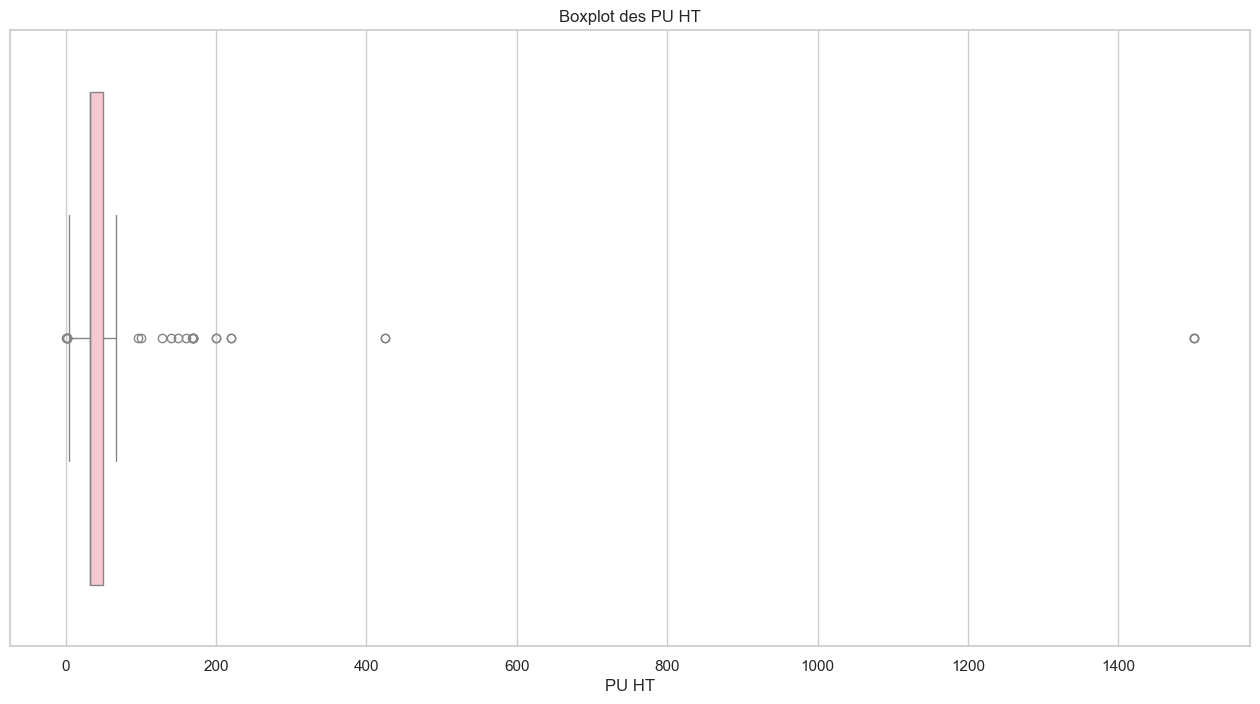

In [77]:
plt.figure(figsize=(16,8))
sns.boxplot(x=Df_FacturesExtraction['PU HT'], color='pink')
plt.title('Boxplot des PU HT')
plt.show()

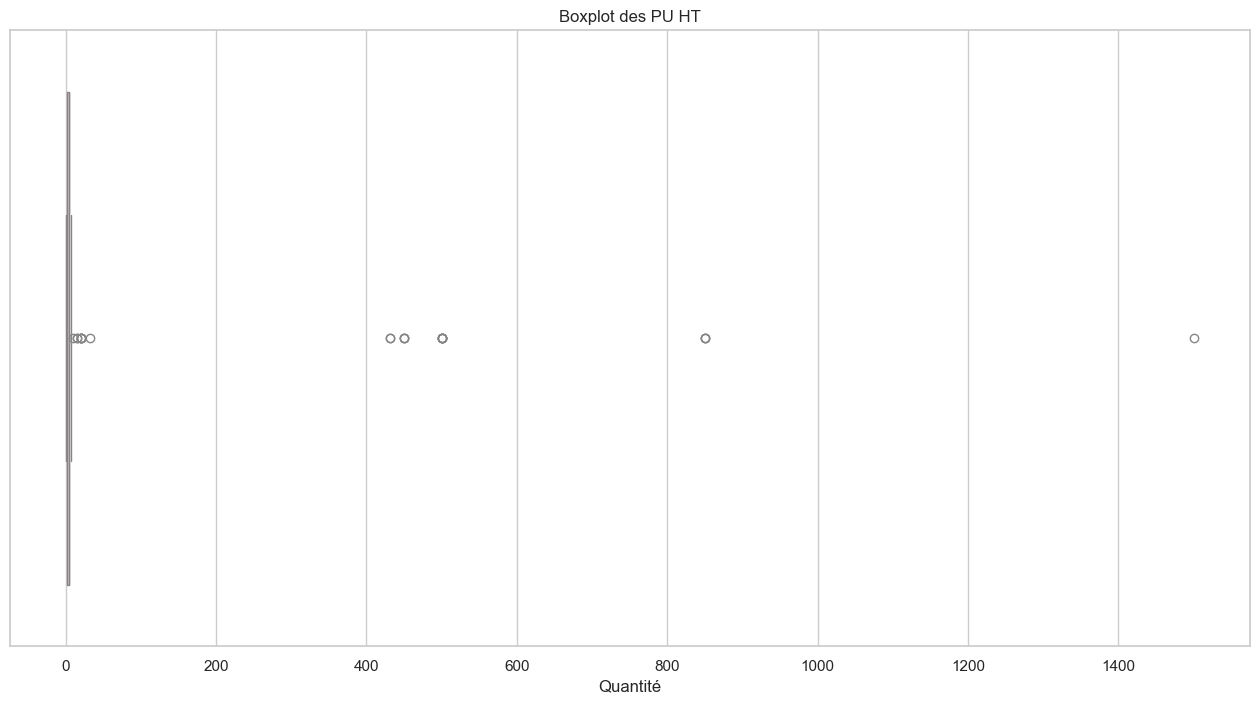

In [78]:
plt.figure(figsize=(16,8))
sns.boxplot(x=Df_FacturesExtraction['Quantité'], color='pink')
plt.title('Boxplot des PU HT')
plt.show()

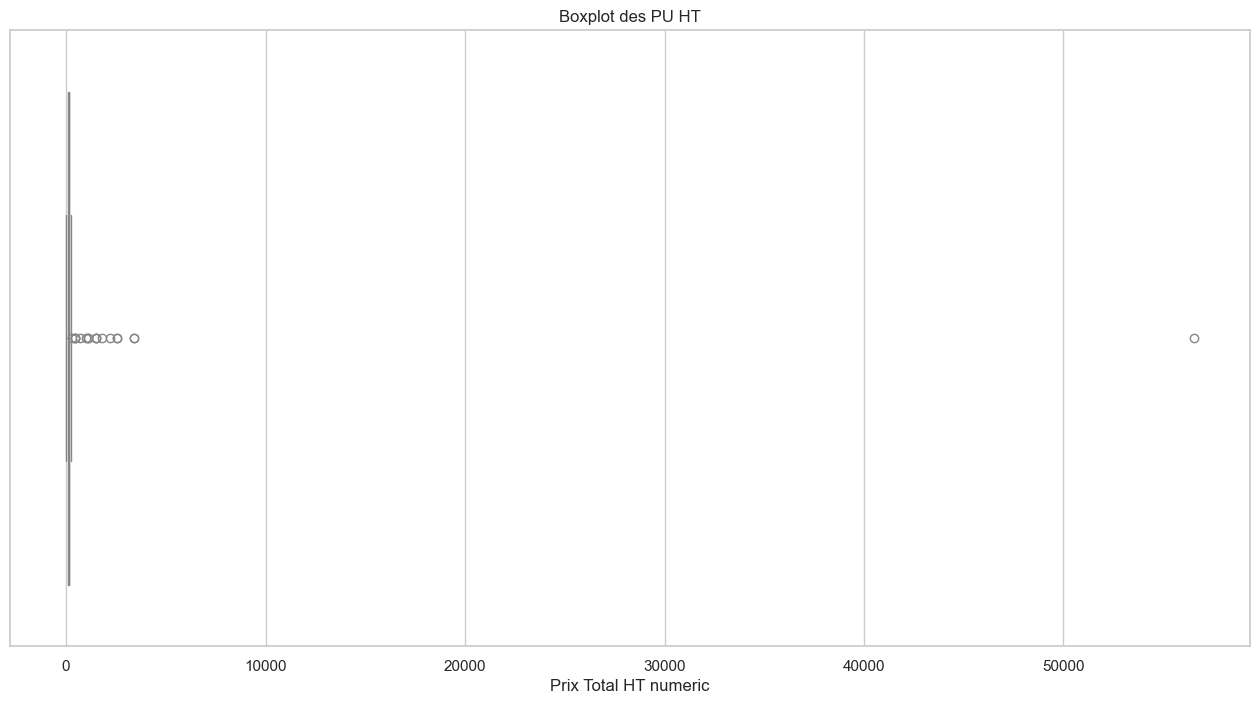

In [81]:
plt.figure(figsize=(16,8))
sns.boxplot(x=Df_FacturesExtraction['Prix Total HT numeric'],color='pink')
plt.title('Boxplot des PU HT')
plt.show()


<span style="color:#B39DDB ">

## **Analyse des corrélations**
</span>

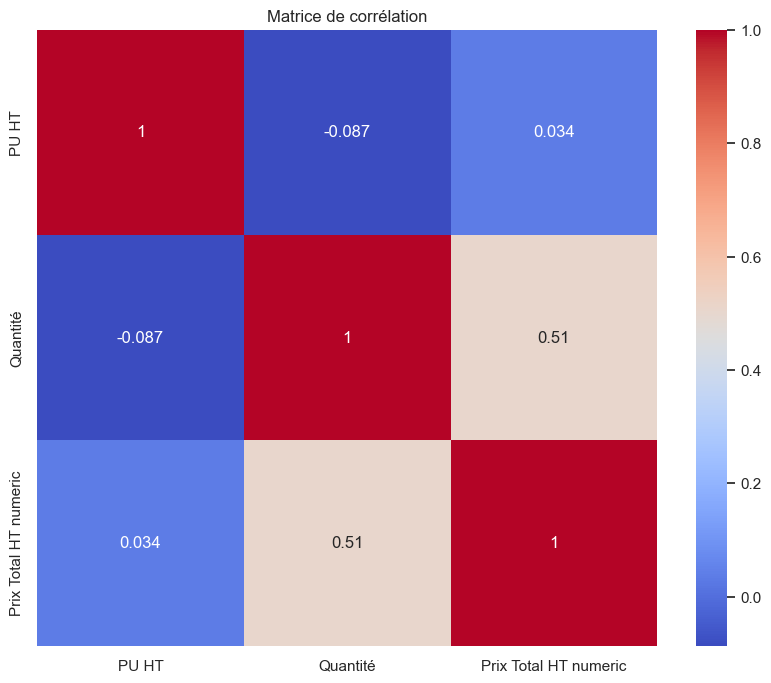

In [83]:
corr = Df_FacturesExtraction[["PU HT", "Quantité", "Prix Total HT numeric"]].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matrice de corrélation')
plt.show()

<span style="color:#B39DDB ">

## **Histogramme des prix par unité**
</span>

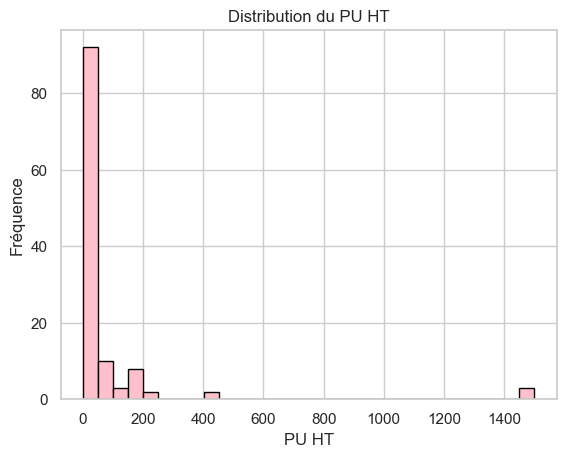

In [84]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(Df_FacturesExtraction["PU HT"].dropna(), bins=30, color="pink", edgecolor="black")
plt.title("Distribution du PU HT")
plt.xlabel("PU HT")
plt.ylabel("Fréquence")
plt.show()


<span style="color:#B39DDB ">

## **Histogramme des Quantités**
</span>

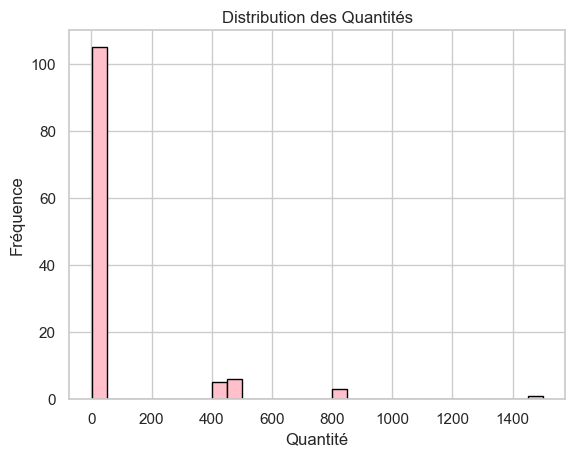

In [85]:
plt.figure()
plt.hist(Df_FacturesExtraction["Quantité"].dropna(), bins=30, color="pink", edgecolor="black")
plt.title("Distribution des Quantités")
plt.xlabel("Quantité")
plt.ylabel("Fréquence")
plt.show()


<span style="color:#B39DDB ">

## **Histogramme des prix totaux HT**
</span>

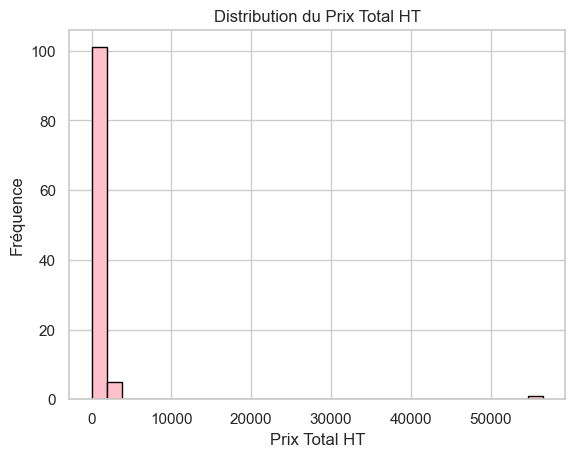

In [87]:
plt.figure()
plt.hist(Df_FacturesExtraction["Prix Total HT numeric"].dropna(), bins=30, color="pink", edgecolor="black")
plt.title("Distribution du Prix Total HT")
plt.xlabel("Prix Total HT")
plt.ylabel("Fréquence")
plt.show()


<span style="color:#B39DDB ">

## **Histogramme du nombre de lignes par facture**
</span>

In [88]:
lignes_par_facture = (
    Df_FacturesExtraction.groupby("Numéro Facture")
      .size()
)


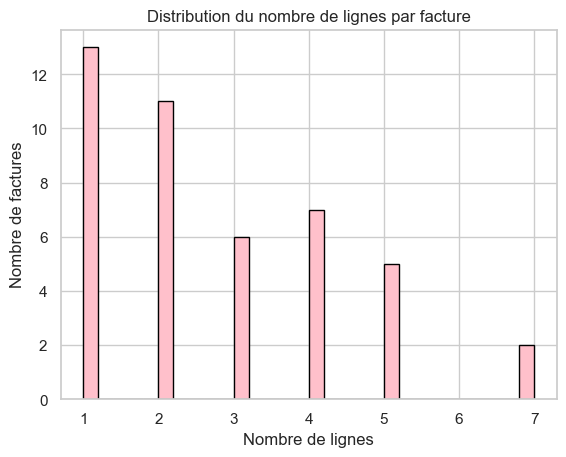

In [89]:
plt.figure()
plt.hist(lignes_par_facture, bins=30, color="pink", edgecolor="black")
plt.title("Distribution du nombre de lignes par facture")
plt.xlabel("Nombre de lignes")
plt.ylabel("Nombre de factures")
plt.show()





<span style="color:#B39DDB ">

## **Problèmes identifiés**
</span>


<span style="color:#B39DDB ">

## **Recommandations**
</span>